# Moduli, numpy, matplotlib

## Osnove modula ``numpy``

Modul ``numpy`` namestimo z upravljalnikom paketov ``pip`` z naslednjim ukazom (v kolikor ga še nimamo nameščenega):
```python
pip install numpy
```
oz. paket posodobimo na najnovešo različico:
```python
pip install numpy --upgrade
```

Najprej uvozimo modul (uveljavljeno je, da ga uvozimo v kratki obliki `np`):

In [1]:
import numpy as np

Gre za enega najbolj pomembnih modulov. Na kratko: gre za visoko optimiran modul za numerične izračune; zelo dobri tutoriali so zbrani na naslovu: [github.com/numpy/numpy-tutorials](https://github.com/numpy/numpy-tutorials). Za odličen uvod v Numpy si lahko ogledate [YouTube posnetek: NumPy Tutorial (2021): For Physicists, Engineers, and Mathematicians](https://www.youtube.com/watch?v=DcfYgePyedM)

Poglejmo si najprej sintakso za vektor ničel ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html)):
```python
numpy.zeros(shape, dtype=float, order='C')
```
argumenti so:

* `shape` definira obliko (lahko večdimenzijsko numerično polje),
* `dtype` definira tip podatka,
* `order` definira vrstni red (lahko je C ali F kot Fortran).

Poglejmo primer:

In [2]:
np.zeros((3,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

ali pa:

In [3]:
np.zeros((3,5))

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

Podobno kot `zeros` se obnaša `ones`, vendar je namesto ničel vrednost 1 ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.ones.html#numpy.ones)). 

Poglejmo si primer, kjer definiramo tudi tip `int` (privzeti tip je `float`):

In [4]:
np.ones(4, dtype=int)

array([1, 1, 1, 1])

Pogosto bomo tudi uporabljali razpon vrednosti `arange` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.arange.html)):
```python
numpy.arange([start, ]stop, [step, ]dtype=None)
```
kjer so argumenti:

* `start` začetna vrednost razpona (privzeto 0),
* `stop` končna vrednost razpona,
* `step` korak in 
* `dtype` tip vrednosti (če tip ni podan, se določi iz ostalih argumentov).

Poglejmo primer razpona od 0 do 9 (kakor vedno pri Pythonu *od* je vključen, *do* pa ni):

In [5]:
np.arange(9)

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

ali pa od 7 do 12 po koraku 2, vendar število s plavajočo vejico:

In [6]:
np.arange(7, 12, 2, dtype=float)

array([ 7.,  9., 11.])

Še eno funkcijo bomo pogosto uporabili, to je `linspace` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)):
```python
numpy.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None)
```
ki definiranemu razponu vrne numerično polje vrednosti na enaki razdalji (ekvidistanten razmik).

Argumenti so:

* `start` začetna vrednost razpona,
* `stop` končna vrednost razpona,
* `num` število točk/vozlišč, 
* `endpoint` ali je vrednost pri `stop` vključena ali ne,
* `retstep` v primeru `True` vrne funkcija terko `(rezultat, korak)`
* `dtype` tip vrednosti (če tip ni podan, se določi iz ostalih argumentov).

Primer generiranja 10 točk na razponu od $-\pi$ do vključno $+\pi$:

In [7]:
np.linspace(-np.pi, np.pi, 10)

array([-3.14159265, -2.44346095, -1.74532925, -1.04719755, -0.34906585,
        0.34906585,  1.04719755,  1.74532925,  2.44346095,  3.14159265])

Mimogrede smo zgoraj spoznali, da ima `numpy` vgrajene konstante (npr. $\pi$): 

Poglejmo še vgrajene funkcije za generiranje naključnih števil. Te najdemo v `numpy.random` ([dokumentacija](https://numpy.org/doc/stable/reference/random/index.html)).

Najprej si poglejmo funkcijo `numpy.random.seed()`, ki se uporablja za ponastavitev generatorja naključnih števil ([dokumentacija](https://numpy.org/doc/stable/reference/random/legacy.html)). To pomeni, da lahko z istim semenom (angl. *seed*) različni uporabniki generiramo ista naključna števila!

**Opomba**: funkcije `numpy.random.seed()`, `rand()`, `random()`, `normal()` itd. spadajo v starejši (*legacy*) vmesnik, ki še vedno deluje. Sodobni pristop je, da si ustvarimo lasten generator in kličemo njegove metode ([dokumentacija](https://numpy.org/doc/stable/reference/random/generator.html)):

```python
rng = np.random.default_rng(0)   # seme 0
rng.random(3)                    # enakomerna porazdelitev na [0, 1)
rng.normal(size=3)               # normalna porazdelitev
```

Spodnja vrstica:

In [8]:
np.random.seed(0)

bo povzročila, da bo klic generatorja naključnih števil z enakomerno porazdelitvijo `numpy.random.rand()` ([dokumentacija](https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html)) vedno rezultiral v iste vrednosti:

In [9]:
np.random.rand(3)

array([0.5488135 , 0.71518937, 0.60276338])

Preizkusimo ali je res, kar smo zapisali, in ponastavimo seme in kličimo generator:

In [10]:
np.random.seed(0)
np.random.random(3)

array([0.5488135 , 0.71518937, 0.60276338])

### Zapis matrik in vektorjev

Matrika je dimenzije ``m x n``, kjer je na prvem mestu ``m`` število vrstic in ``n`` število stolpcev. Primer definiranja matrike dimenzije `m x n = 3 x 2` je: 

In [11]:
a = np.zeros((3, 2))
a

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

Vektor je lahko zapisan kot **vrstični vektor**:

In [12]:
b = np.zeros(3) # (1 x 3)
b

array([0., 0., 0.])

ali kot **stolpični vektor**:

In [13]:
c = np.zeros((3, 1)) # 3 x 1
c

array([[0.],
       [0.],
       [0.]])

V modulu ``numpy`` lahko vektorje in matrike zapisujemo kot:

* `numpy.array` (priporočeno, [dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.array.html)),
* `numpy.matrix` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.matrix.html)). 

Priporočena je prva oblika (`numpy.array`), ki pa ne sledi povsem matematičnemu zapisu (več o tem pozneje), nam pa omogoča **enostavnejše** programiranje in je tudi numerično **bolj učinkovit** pristop ([vir](http://wiki.scipy.org/NumPy_for_Matlab_Users#head-e9a492daa18afcd86e84e07cd2824a9b1b651935)). Pristopa `numpy.matrix` tukaj ne bomo obravnavali.

V angleškem jeziku bomo *array* prevajali kot **večdimenzijsko numerično polje** ali včasih **večdimenzijske sezname** (ker imajo nekatere podobnosti z navadnimi seznami). Nekatere knjige *array* tukaj prevajajo kot *tabela*.

### Rezanje

**Rezanje** (angl. *slicing*) seznamov smo si že pogledali v poglavju Uvod v Python. Podobno rezanje, vendar bolj splošno, velja tudi za numerična polja modula `numpy`. 

Sintaksa rezanja ([dokumentacija](https://numpy.org/doc/stable/user/basics.indexing.html)) je:
```python
numpy_array[od:do:korak]
```
pri tem velja:

* indeksiranje se začne z 0 (kot sicer pri Pythonu),
* **`od`** pomeni **>=**,
* **`do`** pomeni **<**,
* `od`, `do`, `korak` so opcijski parametri,
* če parameter `od` ni podan, pomeni od *začetka*,
* če parameter `do` ni podan, pomeni do vključno zadnjega,
* če parameter `korak` ni podan, pomeni korak 1.

Primer od elementa 3 do elementa 8 po koraku 2:

In [14]:
b = np.arange(10)
b[3:8:2]

array([3, 5, 7])

Primer od elementa 3 naprej:

In [15]:
b[3:]

array([3, 4, 5, 6, 7, 8, 9])

Primer od elementa 3 naprej, vendar vsak tretji:

In [16]:
b[3::3]

array([3, 6, 9])

Primer zadnjih 5 elementov, vendar vsak drugi:

In [17]:
b[-5::2]

array([5, 7, 9])

Primer zadnjih 5 elementov brez zadnjih 2, vendar vsak drugi:

In [18]:
b[-5:-2:2]

array([5, 7])

### Rezanje večdimenzijskega numeričnega polja 

Večdimenzijsko rezanje izvedemo tako, da dimenzije ločimo z vejico:
```python
numpy_array[rezanje0, rezanje1,...]
```
kjer `rezanje0` reže indeks 0 (prvo dimenzijo) v obliki `od:do:korak`, `rezanje1` reže indeks 1 (drugo dimenzijo) in tako naprej.

Poglejmo si primer; najprej pripravimo seznam 15 števil (`np.arange`), nato z metodo `reshape()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html)) spremenimo obliko v matriko `3 x 5`:

In [19]:
a = np.arange(15)
a = a.reshape((3,5))
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

Obliko numeričnega polja lahko preverimo z atributom `shape` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.shape.html)).

In [20]:
a.shape

(3, 5)

Atribute bomo sicer podrobno spoznali pri obravnavi razredov.

Prikažimo vrstice z indeksom 0:

In [21]:
a[0]

array([0, 1, 2, 3, 4])

Isti rezultat bi dobili s prikazom vrstice z indeksom 0 in vseh stolpcev:

In [22]:
a[0,:]

array([0, 1, 2, 3, 4])

Pogosto želimo dostopati do stoplcev, npr. stolpca z indeksom 1 (torej režemo vse vrstice in stolpec z indeksom 1):

In [23]:
a[:,1]

array([ 1,  6, 11])

Poglejmo si še primer rezanja prvih dveh vrstic in zadnjih dveh stolpcev:

In [24]:
a[:2, -2:]

array([[3, 4],
       [8, 9]])

Podobna logika se uporabi pri dimenzijah višjih od 2.

### Operacije nad numeričnimi polji

Poglejmo si sedaj bolj podrobno nekatere osnovne prednosti numeričnega polja `numpy.array` v primerjavi z navadnim seznamom Python.

Najprej pripravimo navaden Pythonov seznam:

In [25]:
a = [1, 2, 3, 4, 5, 6, 7]
a

[1, 2, 3, 4, 5, 6, 7]

In nato še numerično polje `numpy.array` (kar iz seznama `a`):

In [26]:
b = np.array(a)
b

array([1, 2, 3, 4, 5, 6, 7])

Ko izpišemo `b`, smo opozorjeni, da gre za `array([...])`.

Poglejmo, kako se obnaša Pythonov seznam pri množenju:

In [27]:
2*a

[1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7]

Opazimo, da se podvoji seznam, ne pa vrednosti, kar bi morebiti pričakovali.

Poglejmo, kako se pri množenju obnaša numerično polje `numpy.array`:

In [28]:
2*b

array([ 2,  4,  6,  8, 10, 12, 14])

Opazimo, da se podvojijo vrednosti; tako kakor bi pričakovali, ko množimo na primer skalarno vrednost in vektor!

### Aritmetične operacije

Izbor aritmetičnih operacij, ki jih ``numpy`` izvaja na nivoju posameznega elementa, je (po naraščajoči prioriteti):

* `x + y` vsota,	 	 
* `x - y` razlika,	 	 
* `x * y` produkt,	 	 
* `x / y` deljenje,	 	 
* `x // y` celoštevilsko deljenje (rezultat je celo število zaokroženo navzdol),
* `x % y` ostanek pri celoštevilskem deljenju,	 
* `x ** y`	vrne `x` na potenco `y`.

Primer:

In [29]:
b + 3*b - b**2

array([  3,   4,   3,   0,  -5, -12, -21])

Vse aritmetične operacije so sicer navedene v [dokumentaciji](https://numpy.org/doc/stable/reference/routines.math.html#arithmetic-operations) in namesto kratkih oblik imamo tudi *dolge*, npr: `numpy.power(x, y)` namesto `x**y`; primer:

In [30]:
np.power(b, 2)

array([ 1,  4,  9, 16, 25, 36, 49])

Mimogrede opazimo, da je rezultat tipa `int64` (integer). Ko smo ustvarili ime `b`, smo namreč ustvarili numerično polje z elementi tipa `int64`.

### Matematične funkcije

`numpy` ponuja praktično vse potrebne matematične (in druge) operacije, navedimo jih po skupinah, kot so strukturirane v [dokumentaciji](https://numpy.org/doc/stable/reference/routines.math.html#mathematical-functions):

* [trigonometrične funkcije](https://numpy.org/doc/stable/reference/routines.math.html#trigonometric-functions),
* [hiperbolične](https://numpy.org/doc/stable/reference/routines.math.html#hyperbolic-functions),
* [funkcije za zaokroževanje](https://numpy.org/doc/stable/reference/routines.math.html#rounding),
* [funkcije za vsoto, produkt in odvod](https://numpy.org/doc/stable/reference/routines.math.html#sums-products-differences),
* [eksponenti in logaritmi](https://numpy.org/doc/stable/reference/routines.math.html#exponents-and-logarithms),
* [posebne](https://numpy.org/doc/stable/reference/routines.math.html#other-special-functions) ter [preostale](https://numpy.org/doc/stable/reference/routines.math.html#miscellaneous) funkcije.

Poglejmo primer funkcije $\sin()$:

In [31]:
a = np.linspace(0, 2*np.pi, 5)
np.sin(a)

array([ 0.0000000e+00,  1.0000000e+00,  1.2246468e-16, -1.0000000e+00,
       -2.4492936e-16])

Poglejmo še hitrost izvajanja:

In [32]:
%timeit -n100 np.sin(a)

437 ns ± 38.9 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Podatkovni tipi

``numpy`` ima vnaprej definirane podatkovne tipe (statično). Celoten seznam možnih tipov je naveden v [dokumentaciji](https://numpy.org/doc/stable/reference/arrays.dtypes.html).

Osredotočili se bomo predvsem na sledeče tipe:

* ``int`` - celo število (fiksne širine, običajno 64 bitov; za razliko od Pythonovega `int` lahko prekorači obseg)
* ``float`` - število s plavajočo vejico ([dokumentacija](https://docs.python.org/dev/library/functions.html#float))
* ``complex`` - kompleksno število s plavajočo vejico
* ``object`` - Python objekt.

Poglejmo si nekaj primerov (cela števila, število s plavajočo vejico in kompleksna števila):

In [33]:
np.arange(5, dtype=int)

array([0, 1, 2, 3, 4])

In [34]:
np.arange(5, dtype=float)

array([0., 1., 2., 3., 4.])

In [35]:
np.arange(5, dtype=complex)

array([0.+0.j, 1.+0.j, 2.+0.j, 3.+0.j, 4.+0.j])

### Spreminjanje elementov numeričnega polja (`numpy.array`)

Podatke spreminjamo na podoben način kakor pri navadnih seznamih; v kolikor uporabljamo rezanje, moramo paziti, da so na levi in desni strani enačaja podatki iste oblike (`array.shape`).

Poglejmo si primer, ko matriki ničel dimenzije `3 x 4` spremenimo element z indeksom `[2, 3]`:

In [36]:
a = np.zeros((3, 4))
a[2, 3] = 100
a

array([[  0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.],
       [  0.,   0.,   0., 100.]])

Sedaj spremenimo še elemente prvih dveh vrstic in prvih dveh stolpcev v vrednost 1:

In [37]:
a[:2, :2] = np.ones((2, 2))
a

array([[  1.,   1.,   0.,   0.],
       [  1.,   1.,   0.,   0.],
       [  0.,   0.,   0., 100.]])

Z 2 pomnožimo stolpec z indeksom 1:

In [38]:
a[:,1] = 2 * a[:,1]
a

array([[  1.,   2.,   0.,   0.],
       [  1.,   2.,   0.,   0.],
       [  0.,   0.,   0., 100.]])

Bodite pozorni na to, da na tak način naredimo *pogled* (view) na podatke (**ne naredimo kopije podatkov**). 

Za primer najprej naredimo novo ime `pogled`:

In [39]:
pogled = a[:, 2]
pogled

array([0., 0., 0.])

Sedaj spremenimo izbrane vrednosti numeričnega polja `a`:

In [40]:
a[:, 2] = 5
a

array([[  1.,   2.,   5.,   0.],
       [  1.,   2.,   5.,   0.],
       [  0.,   0.,   5., 100.]])

Vrednosti `pogled` nismo spreminjali. Ker pa ime kaže na isto mesto kakor `a[:, 2]`, so vrednosti spremenjene:

In [41]:
pogled

array([5., 5., 5.])

Če želimo kopijo, moramo narediti tako:

In [42]:
kopija = a[:, 2].copy()
kopija

array([5., 5., 5.])

in rezultat `kopija` ostane nespremenjen:

In [43]:
a[:, 2] = 2
kopija

array([5., 5., 5.])

### Osnove matričnega računanja

Če želite ponoviti matematične osnove matričnega računanja, potem sledite tej [povezavi](http://www.fmf.uni-lj.si/~kosir/poucevanje/skripta/matrike.pdf) (gre za kratek in dober pregled prof. dr. T. Koširja). Pogledali bomo, kako matrične račune izvedemo s pomočjo paketa `numpy`.

Najprej definirajmo matriki $\mathbf{A}$ in $\mathbf{B}$:

In [44]:
A = np.array([[1, 2], [3, 2]])
B = np.array([[1, 1], [2, 2]])

ter vektorja $\mathbf{x}$ in $\mathbf{y}$.

In [45]:
x = np.array([1, 2])
y = np.array([3, 4])

Skalarni produkt dveh vektorjev izvedemo s funkcijo `dot()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)):
```python
numpy.dot(a, b, out=None)
```
kjer argumenta `a` in `b` predstavljata numerični polji `numpy.array` (poljubne dimenzije), ki jih želimo množiti. Če sta `a` in `b` dimenzije 1 se izvede skalarni produkt. Pri dimenziji 2 (matrike) se izračuna produkt matrik. Za uporabo funkcije `dot()` pri dimenzijah več kot 2: glejte [dokumentacijo](https://numpy.org/doc/stable/reference/generated/numpy.dot.html).

Poglejmo primer množenja dveh vektorjev, to lahko izvedemo tako:

In [46]:
np.dot(x, y)

np.int64(11)

ali tudi tako:

In [47]:
x.dot(y)

np.int64(11)

Zgoraj smo omenili, da `numpy.array` ne sledi dosledno matematičnemu zapisu. Če bi, bi namreč eden od vektorjev moral biti vrstični, drugi stolpični. `numpy` to poenostavi in zato je koda lažje berljiva in krajša.

Poglejmo sedaj množenje matrike z vektorjem (opazimo, da transponiranje `x` ni potrebno):

In [48]:
np.dot(A, x)

array([5, 7])

Lahko pa seveda pripravimo matematično korektno transponirano obliko vektorja (ampak vidimo, da je zapis neroden):

In [49]:
A.dot(np.transpose([x]))

array([[5],
       [7]])

Transponiranje ima sicer tudi kratko obliko, prek atributa `T`, npr. za matriko $\mathbf{A}$:

In [50]:
A.T

array([[1, 3],
       [2, 2]])

Poglejmo si primer množenja dveh matrik:

In [51]:
np.dot(A, B)

array([[5, 5],
       [7, 7]])

Od Pythona 3.5 naprej se za množenje matrik (in vektorjev) uporablja tudi operator `@` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html#numpy.matmul)), ki omogoča kratek in pregleden zapis.

Zgornji primeri zapisani z operatorjem `@`:

In [52]:
x @ y

np.int64(11)

In [53]:
A @ x

array([5, 7])

In [54]:
A @ B

array([[5, 5],
       [7, 7]])

**Vektorski produkt** izračunamo s funkcijo `numpy.cross()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.cross.html)):
```python
numpy.cross(a, b, axisa=-1, axisb=-1, axisc=-1, axis=None)
```
kjer `a` in `b` definirata komponente vektorjev. Vektorja morata imeti tri komponente, rezultat je vektor s tremi komponentami. Ravninske vektorje (samo komponenti $x$ in $y$) NumPy od različice 2.0 ne sprejme več; dopolnimo jih s komponento $z=0$, rezultat pa ima neničelno le komponento $z$. Uporaba funkcije je možna tudi na večdimenzijskih numeričnih poljih in temu so namenjeni preostali argumenti (glejte dokumentacijo).

Primer vektorskega produkta ravninskih vektorjev:

In [55]:
x = np.array([1, 0])
y = np.array([0, 1])
np.cross(np.append(x, 0), np.append(y, 0))[2] # dopolnimo z z=0 in vzamemo komponento z

np.int64(1)

Primer vektorskega produkta prostorskih vektorjev:

In [56]:
x = np.array([1, 0, 0])
y = np.array([0, 1, 0])
np.cross(x, y)

array([0, 0, 1])

### Nekatere funkcije knjižnice ``numpy``

Pogledali si bomo še nekatere funkcije, ki jih bolj ali manj pogosto potrebujemo.

Enotsko matriko definiramo s funkcijo `numpy.identity()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.identity.html)):
```python
numpy.identity(n, dtype=None)
```
kjer argument `n` definira število vrstic in stolpcev kvadratne matrike. Tip `dtype` je privzeto `float`.

Primer enotske matrike:

In [57]:
A = np.identity(3)
A

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

Do diagonalnih elementov matrike dostopamo s pomočjo funkcije `numpy.diagonal()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.diagonal.html))
```python
numpy.diagonal(a, offset=0, axis1=0, axis2=1)
```
Če je matrika dvodimenzijska, potem funkcija s privzetimi argumenti vrne diagonalno os. Če je dimenzija višja od 2, se uporabi osi `axis1` in `axis2`, da se izloči dvodimenzijsko polje, nato pa določi diagonalo glede na elemente `[i, i+offset]`.

Poglejmo primer izločanja diagonale:

In [58]:
np.diagonal(A)

array([1., 1., 1.])

in uporabe `offset=1` za sosednjo diagonalo (najprej pripravimo nesimetirčno matriko):

In [59]:
A[0, 1] = 10
np.diagonal(A, offset=1)

array([10.,  0.])

Podobno sintakso kot `numpy.diagonal()` ima funkcija `numpy.trace()`, ki izračuna vsoto (sled) diagonalnih elementov ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.trace.html)):
```python
numpy.trace(a, offset=0, axis1=0, axis2=1, 
            dtype=None, out=None)
```

Primer sledi diagonale:

In [60]:
np.trace(A)

np.float64(3.0)

in potem sosednje diagonale:

In [61]:
np.trace(A, offset=1)

np.float64(10.0)

Pogosto nas zanimata največji ali najmanjši element nekega numeričnega polja. `numpy` je tukaj zelo splošen. Poglejmo si na primeru funkcije `numpy.max()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.max.html)):
```python
numpy.max(a, axis=None, out=None)
```
Izpostavimo argument `axis`, ki pove, čez kateri indeks iščemo maksimalno vrednost. Če je `axis=None` se določi največja vrednost v celotnem polju.

Primer izračuna največje vrednosti celotnega polja (prej poglejmo `A`):

In [62]:
A

array([[ 1., 10.,  0.],
       [ 0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [63]:
np.max(A)

np.float64(10.0)

Primer izračuna največje vrednosti čez vrstice (torej po stolpcih):

In [64]:
np.max(A, axis=0)

array([ 1., 10.,  1.])

Primer izračuna največje vrednosti čez stolpce (torej po vrsticah):

In [65]:
np.max(A, axis=1)

array([10.,  1.,  1.])

Par funkcije `max()` je `numpy.argmax()`, kateri določi indekse največje vrednosti.

Primer uporabe:

In [66]:
A

array([[ 1., 10.,  0.],
       [ 0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [67]:
np.argmax(A, axis=0)

array([0, 0, 2])

### Linearna algebra z ``numpy``

Pozneje bomo linearno algebro bolj podrobno spoznali in bomo sami pisali algoritme. Tukaj si poglejmo nekatere osnove, ki so vgrajene v modul `numpy`.

Za primer najprej definirajmo matriko in vektor:

In [68]:
A = np.array([[4, -2],
              [-2, 4]])
b = np.array([1, 2])

Inverzno matriko izračunamo z uporabo funkcije `numpy.linalg.inv()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)):
```python
numpy.linalg.inv(a)
```

In [69]:
np.linalg.inv(A)

array([[0.33333333, 0.16666667],
       [0.16666667, 0.33333333]])

Sistem linearnih enačb, ki ga definirata matrika koeficientov `a` in vektor konstant `b`, rešimo s pomočjo funkcije `numpy.linalg.solve()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)):
```python
numpy.linalg.solve(a, b)
```

Primer:

In [70]:
rešitev = np.linalg.solve(A, b)
rešitev

array([0.66666667, 0.83333333])

Enakost elementov numeričnega polja `a` in `b` (znotraj določene tolerance) preverimo s funkcijo `numpy.isclose()` ([dokumentacija](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html)):
```python
numpy.isclose(a, b, rtol=1e-05, atol=1e-08, equal_nan=False)
```

Primer:

In [71]:
np.isclose(np.dot(A, rešitev), b)

array([ True,  True])

### Vektorizacija algoritmov

V tem poglavju želimo izpostaviti vektorizacijo algoritmov. Glede na to kako Python in `numpy` delujeta se je potrebno izogibati zankam. Bistveno hitreje lahko izvajamo izračune, če jih uspemo vektorizirati; to pomeni, da izračune izvajamo na nivoju vektorjev (oz. numeričnih polj) in ne elementov.

Za primer si najprej pripravimo podatke (dva vektorja dolžine 1000)

In [72]:
N = 1000
a = np.arange(N)
b = np.arange(N)

Izračunajmo skalarni produkt vektorjev z uporabo zanke `for`:

In [73]:
c = 0
for i in range(N):
    c += a[i] * b[i]
c

np.int64(332833500)

Izmerimo hitrost:

In [74]:
%%timeit -n100
c = 0
for i in range(N):
    c += a[i] * b[i]

183 μs ± 1.75 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Isti rezultat pridobimo še v vektorski obliki:

In [75]:
%%timeit -n100
c = a @ b

1.44 μs ± 131 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


Vidimo, da je vektorski način bistveno hitrejši (za še hitrejši način glejte `numba` v dodatku)!

## Osnove modula ``matplotlib``

V Pythonu imamo več možnosti za prikaz rezultatov v grafični obliki. Najbolj uporabni paketi so:

* [`matplotlib`](http://matplotlib.org/) za visoko kakovostne, visoko prilagodljive slike (relativno počasno),
* [`pyqtgraph`](http://www.pyqtgraph.org/) za kakovostne in prilagodljive uporabniške vmesnike (zelo hitro),
* [`bokeh`](https://bokeh.pydata.org/en/latest/) za interaktiven prikaz v brskalniku (relativno hitro).

Obstaja še veliko drugih; dober pregled je naredil Jake VanderPlas na konferenci [PyCon 2017](https://www.youtube.com/watch?v=FytuB8nFHPQ) (sicer avtor paketa za deklarativno vizualizacijo: *Altair*).

### Osnovna uporaba

Najbolj razširjen in najbolj splošno uporabljen je paket [`matplotlib`](http://matplotlib.org/):
![Matplotlib](https://matplotlib.org/stable/_static/logo2.svg)

Sposobnosti paketa najbolje prikazuje [galerija](https://matplotlib.org/stable/gallery/index.html). Gre za zelo sofisticiran paket in tukaj si bomo na podlagi primerov pogledali nekatere osnove.

Pri uporabi vam lahko koristi [plonk listek](https://github.com/rougier/matplotlib-cheatsheet):
![Matplotlib cheatsheet](https://raw.githubusercontent.com/rougier/matplotlib-cheatsheet/master/matplotlib-cheatsheet.png)

Tipično uvozimo `matplotlib.pyplot` kot `plt`:

In [76]:
import matplotlib.pyplot as plt

Znotraj *Jupyter notebooka* obstajata dva načina prikaza slike (v oglatem oklepaju je magic ukaz za proženje):

1. `[%matplotlib inline]   `: slike so vključene v notebook (**medvrstični** način),
1. `[%matplotlib widget]   `: slike so interaktivno vključene v notebook (**medvrstični interaktivni** način), zahteva namestitev paketa **ipympl**,

3. `[%matplotlib notebook] `: slike so interaktivno vključene v notebook (**medvrstični interaktivni** način).

Opomba: *interaktivni način se v pasivni, spletni/pdf verziji te knjige ne prikaže pravilno*.

Tukaj bomo najpogosteje uporabljali *medvrstični* način:

In [77]:
%matplotlib inline

Kratek primer:

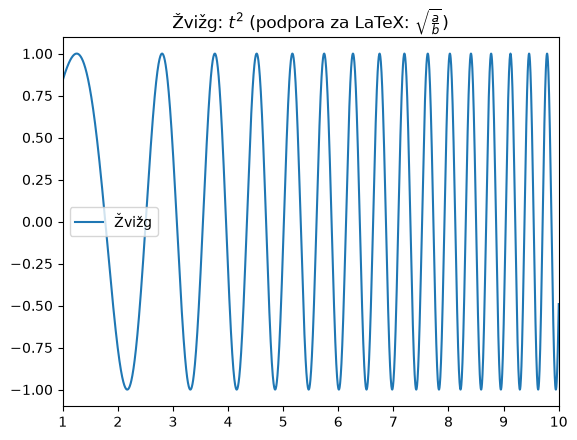

In [78]:
t = np.linspace(1, 130, 44000)
žvižg = np.sin(t**2)
plt.plot(t, žvižg, label='Žvižg')
plt.xlim(1, 10)
plt.title('Žvižg: $t^2$ (podpora za LaTeX: $\\sqrt{\\frac{a}{b}}$)')
plt.legend();
plt.show()

Mimogrede, zakaj to imenujemo žvižg (oz. kvadraten žvižg)? Da dobimo odgovor, podatke predvajamo na zvočnik:

In [79]:
from IPython.display import Audio, display
display(Audio(data=žvižg, rate=44000))

Aktivirajmo sedaj interaktivni način (glejte tudi ``%matplotlib``):

In [80]:
%matplotlib notebook
%matplotlib notebook

In [81]:
plt.plot([1,2,3], [2,4,5]);

<IPython.core.display.Javascript object>

Zgornjo sliko lahko sedaj interaktivno klikamo in tudi dopolnjujemo s kodo:

In [82]:
plt.title('Pozneje dodani naslov!')
plt.xlabel('Čas [$t$]');

### Interaktivna uporaba

Pri tem predmetu bomo večkrat uporabljali interaktivnost pri delu z grafičnimi prikazi. V ta namen najprej uvozimo `interact` iz paketa `ipywidgets`:

In [83]:
from ipywidgets import interact

Potem definiramo sliko kot funkcijo z argumenti `amplituda`, `fr`, `faza` in `dušenje`:

In [84]:
def slika(amplituda=1, fr=10, faza=0, dušenje=0.):
    t = np.linspace(0, 1, 200)
    f = amplituda * np.sin(2*np.pi*fr*t - faza) * np.exp(-dušenje*2*np.pi*fr*t)
    plt.plot(t, f)
    plt.ylim(-5, 5)
    plt.show()

Gremo nazaj na medvrstično uporabo in kličemo funkcijo za izris slike (privzeti argumenti):

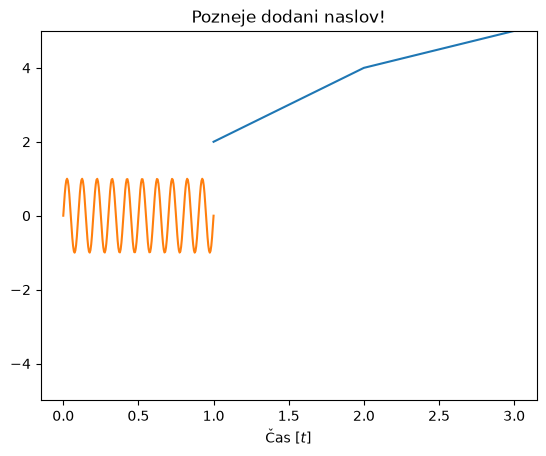

In [85]:
%matplotlib inline
slika()

Če funkcijo za izris slike pošljemo v funkcijo `interact`, slednja poskrbi za interaktivne gumbe, s katerimi lahko spreminajmo parametre klicanja funkcije `slika`:

In [86]:
interact(slika);

interactive(children=(IntSlider(value=1, description='amplituda', max=3, min=-1), IntSlider(value=10, descript…

Razpon parametov lahko tudi sami definiramo:

In [87]:
interact(slika, amplituda=(1, 5, 1), dušenje=(0, 1, 0.05), fr=(10, 100, 1), faza=(0, 2*np.pi, np.pi/180));

interactive(children=(IntSlider(value=1, description='amplituda', max=5, min=1), IntSlider(value=10, descripti…

### Napredna uporaba

#### Prikaz več funkcij

Poglejmo si preprost primer prikaza več funkcij (najprej, opcijsko, definirajmo fonte za izpis v pdf):

In [88]:
from matplotlib import rc
rc('font',**{'family':'serif'})
plt.rcParams['pdf.fonttype'] = 42

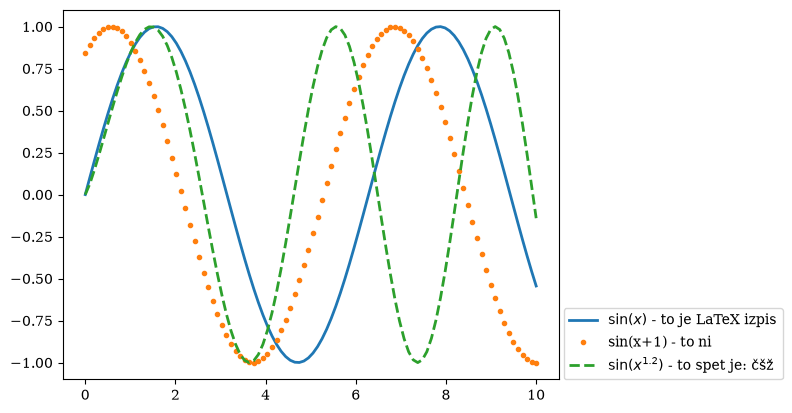

In [89]:
x = np.linspace(0, 10, 100)

y1 = np.sin(x)
y2 = np.sin(x+1)
y3 = np.sin(x**1.2)

plt.plot(x, y1, '-', label=r'$\sin(x)$ - to je LaTeX izpis', linewidth = 2);
plt.plot(x, y2, '.', label='sin(x+1) - to ni', linewidth = 2);
plt.plot(x, y3, '--', label=r'$\sin(x^{1.2})$ - to spet je: čšž', linewidth = 2);
plt.legend(loc=(1.01,0)); 
plt.savefig('data/prvi plot.pdf')

#### Prikaz več slik

Več slik prikažemo s pomočjo metode `subplot`, ki definira mrežo in lego naslednjega izrisala.
```python
plt.subplot(2, 2, 1)
plt.plot(x, y1, 'r')
plt.subplot(2, 2, 2)
plt.plot(x, y2, 'g')
```
V primeru zgoraj `plt.subplot(2, 2, 1)` pomeni: mreža naj bo `2 x 2`, riši v sliko 1 (levo zgoraj). Naslednjič se kliče `plt.subplot(2, 2, 2)` kar pomeni mreža `2 x 2`, riši v sliko 2 (desno zgoraj) in tako naprej. Opazimo, da se indeks slik začne z 1; lahko bi rekli, da gre za nekonsistentnost v Pythonu, razlog pa je v tem, da je bil `matplotlib` rojen v ideji, da bi uporabnikom Pythona uporabil čimbolj podoben način izrisa, kakor so ga poznali v Matlabu (kjer se indeks začne z 1).

Delujoči primer je:

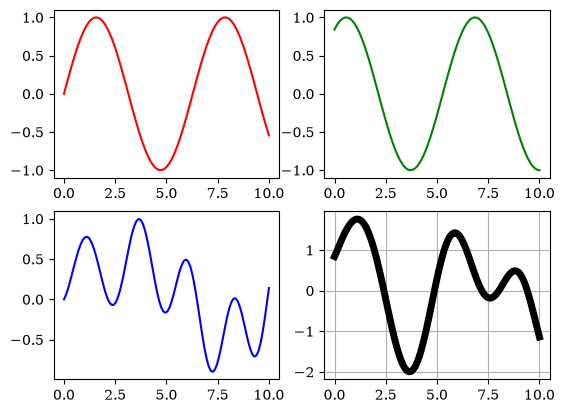

In [90]:
plt.subplot(2, 2, 1)
plt.plot(x, y1, 'r')
plt.subplot(2, 2, 2)
plt.plot(x, y2, 'g')
plt.subplot(2, 2, 3)
plt.plot(x, y2*y3, 'b')
plt.subplot(2, 2, 4)
plt.plot(x, y2+y3, 'k', linewidth=5);
plt.grid()

#### Histogram

Generirajmo 10000 normalno porazdeljenih vzorcev in jih prikažimo v obliki histograma:

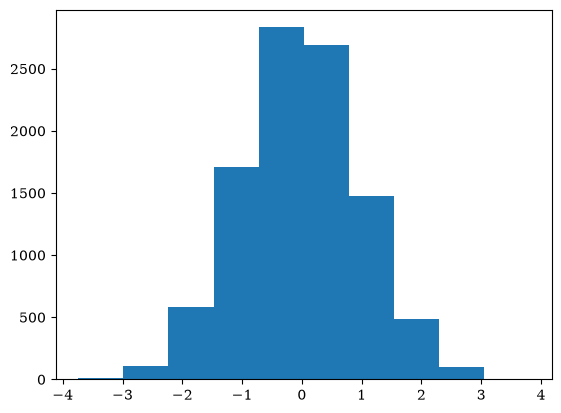

In [91]:
np.random.seed(0)
x = np.random.normal(size=10000)
plt.hist(x);

### Uporaba primerov iz ``matplotlib.org``

Primere iz [galerije](https://matplotlib.org/stable/gallery/index.html) lahko uvozimo s pomočjo magične funkcije `%load`.

Poskusite:

* `%load http://matplotlib.org/mpl_examples/lines_bars_and_markers/fill_demo.py`
* `%load http://matplotlib.org/examples/widgets/slider_demo.py`

# Dodatno: 
## `Numba`

Paket `numba` se v zadnjem obdobju zelo razvija in lahko numerično izvajanje še dodatno pohitri (tudi v povezavi z grafičnimi karticami oz. GPU procesorji). 

Za zgled tukaj uporabimo `jit` ([just-in-time compilation](http://numba.pydata.org/numba-doc/dev/reference/jit-compilation.html)) iz paketa `numba`:

In [92]:
import numpy as np
from numba import jit

`jit` uporabimo kot [dekorator](https://docs.python.org/3/glossary.html#term-decorator) funkcije, ki jo želimo pohitriti:

In [93]:
@jit
def skalarni_produkt(a, b):
    c = 0
    for i in range(N):
        c += a[i] * b[i]
    return c

Sedaj definirajmo vektorja:

In [94]:
N = 1000
a = np.arange(N)
b = np.arange(N)

Preverimo hitrost `numpy` skalarnega produkta:

In [95]:
%%timeit -n1000
a @ b

1.48 μs ± 43.1 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Preverimo še hitrost `numba` pohitrene verzije. Prvi klic izvedemo, da se izvede kompilacija, potem merimo čas:

In [96]:
skalarni_produkt(a, b)

332833500

In [97]:
%%timeit -n1000
skalarni_produkt(a, b)

808 ns ± 114 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Vidimo, da smo še izboljšali hitrost!

## `matplotlib`: animacije, povratni klic, XKCD stil

Z `matplotlib` lahko pripravimo tudi **animacije**. Dva primera lahko najdete tukaj:

* [Preprosta animacija](./moduli/matplotlib_animacija.py),
* [Dvojno nihalo](./moduli/animacija_dvojno_nihalo.py).

Več v [dokumentaciji](https://matplotlib.org/api/animation_api.html#animation).

Slika s **povratnim klicem** (angl. *call back*):

* [Risanje črte](./moduli/matplotlib_klik.py).

Pripravite lahko tudi *na roko* narisane slike (**XKCD stil**):

* [XKCD stil](./moduli/xkcd_stil.py).

## Za najbolj zagrete

1. Naučite se še kaj novega na [chrisalbon.com](http://chrisalbon.com/).

---

# Vprašanja za vaje

---

## Modul ``numpy``

**Vprašanje 1:** Uvozite modul ``numpy`` s krajšim imenom, ``np``.

Poljuben seznam števil pretvorite v ``numpy`` numerično polje, prikažite vpliv argumenta ``dtype``.

**Vprašanje 2:** z uporabo funkcij ``numpy.arange`` in ``numpy.linspace`` pripravite numerično polje celih števil, večjih ali enakih 0 in manjših od 10.

**Vprašanje 3:** Z uporabo funkcije modula ``numpy`` pripravite matriko (dvodimenzionalno numerično polje) ničel, dimenzij $5 \times 6$, in jo shranite v spremenljivko ``A``. 

Z uporabo ustreznega  ``numpy`` ukaza izpišite število vrstic in število stolpcev matrike ``A``.

**Vprašanje 4:** Prvi stolpec pripravljene matrike ``A`` zapolnite z vrednosti iz poljubnega numeričnega polja ustrezne dolžine.

**Vprašanje 5:** Iz pripravljene matrike ``A`` z rezanjem numeričnih polj pripravite kvadratno matriko ``B``, tako, da izpustite prvi stolpec.

**Vprašanje 6:** V matriki ``A`` prvo vrstico zamenjajte z enicami. Izpišite matriko ``B`` in komentirajte.

### Operacije nad numeričnimi polji

**Vprašanje 7:** Pripravite numerično polje z vrednostmi maksimalnih elementov vsake od vrstic pripravljene matrike A.

**Vprašanje 8:** Na pripravljenem numeričnem polju opazujte uporabo osnovnih matematičnih operacij nad numeričnimi polji (``*, /, //, sin, cos, sqrt``...). 

Komentirajte razliko v primerjavi s seznami!

### Linearna algebra z ``numpy``

**Vprašanje 9:** Pripravite enotsko matriko ``I``. Pomnožite jo s poljubnim vektorjem ustrezne dolžine.																							

**Vprašanje 10:** Izračunajte inverz matrike ``M`` in pravilnost rezultata preverite z  operacijo množenja matrik.

In [107]:
# Podatek
M = np.array([[1, 5, 5], [2,1,3], [7.2, 7, 1.2]])

**Vprašanje 11:** Z uporabo ``numpy`` orodij rešite sistem linearnih enačb ``Mx = b``.

In [109]:
# Podatek
M = np.array([[1, 5, 5], [2,1,3], [7.2, 7, 1.2]])
b = np.array([1,2,3])

-------

## Modul ``matplotlib``

In [111]:
from matplotlib import pyplot as plt

**Vprašanje 12:** Z uporabo ``matplotlib.pyplot`` na istem grafu izrišite spodaj definiranje krivulje. Prikažite uporabo različnih tipov in barv črt.

In [112]:
# Podatek
t = np.linspace(1,10,300)
x = 2*np.sin(t+2) -1
y = 2*np.sin(t)
z = 1.5*np.cos(t**2)

**Vprašanje 13:** Na zgoraj izrisanem grafu prikažite uporabo legende, naslova in oznak koordinatnih osi, ter izrišite koordinatno mrežo.